# Exploring Last Millennium Reanalysis (LMR) Precipitation over Alabama

### Overview
This notebook compares reconstructed precipitation from the NOAA Last Millennium Reanalysis (LMR) at Lake Touson Alabama. We’ll subset the region, compute mean precipitation, and visualize trends, anomalies, and distributions.

By completing this notebook, you’ll learn how to:

- Load and explore NetCDF using xarray and pandas

- Subset regional climate data using latitude/longitude bounds

- Visualize precipitation trends, and century-scale distributions

- Interpreting reanalysis and paleoclimate data for regional applications

# Imports

In [33]:
import xarray as xr
import cftime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import s3fs

#### Load LMR Dataset

In [34]:
jetstream_url = 'https://js2.jetstream-cloud.org:8001/'

s3 = s3fs.S3FileSystem(anon=True, client_kwargs=dict(endpoint_url=jetstream_url))

s3path = 's3://pythia/reconstructions/tardiflmr/prate_MCruns_ensemble_mean_LMRv2.1.nc'

# Open the file
s3file = s3.open(s3path)

# Open with xarray
lmr = xr.open_dataset(s3file)
lmr

<xarray.Dataset> Size: 3GB
Dimensions:  (time: 2001, MCrun: 20, lat: 91, lon: 180)
Coordinates:
  * time     (time) object 16kB 0000-01-01 00:00:00 ... 2000-01-01 00:00:00
  * lat      (lat) float32 364B -90.0 -88.0 -86.0 -84.0 ... 84.0 86.0 88.0 90.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Dimensions without coordinates: MCrun
Data variables:
    prate    (time, MCrun, lat, lon) float32 3GB ...
Attributes:
    description:  Last Millennium Reanalysis climate field reconstruction for...
    experiment:   productionFinal2_gisgpcc_ccms4_LMRdbv1.1.0_pr
    comment:      File contains ensemble-mean values for each Monte-Carlo rec...

### Decode time

In [35]:
time_var = lmr['time'].values
decoded_time = [cftime.DatetimeNoLeap(y.year, 1, 1) for y in time_var]
years= [t.year for t in decoded_time]

### Assign decoded time back into dataset and make sure that it worked!

In [36]:
lmr = lmr.assign_coords(time=decoded_time)

print("✅ Time fixed!")
print("Start:", lmr.time.values[0])
print("End:", lmr.time.values[-1])
#years = [t.year for t in lmr.time.values]
print("Years span:", min(years), "to", max(years))

✅ Time fixed!
Start: 0000-01-01 00:00:00
End: 2000-01-01 00:00:00
Years span: 0 to 2000


### Select precipiation variable "prate" and get full information

In [37]:
pr = lmr['prate']  
print(pr)

<xarray.DataArray 'prate' (time: 2001, MCrun: 20, lat: 91, lon: 180)> Size: 3GB
[655527600 values with dtype=float32]
Coordinates:
  * time     (time) object 16kB 0000-01-01 00:00:00 ... 2000-01-01 00:00:00
  * lat      (lat) float32 364B -90.0 -88.0 -86.0 -84.0 ... 84.0 86.0 88.0 90.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Dimensions without coordinates: MCrun
Attributes:
    var_desc:       Precipitation rate at surface
    long_name:      Precipitation Rate at Surface
    standard_name:  precipitation_flux
    units:          kg/m^2/s
    level_desc:     Surface
    statistic:      Ensemble Mean
    GRIB_id:        59
    GRIB_name:      PRATEsfcAvg
    valid_range:    [-0.0002  0.0002]
    dataset:        NOAA Last Millennium Reanalysis version 1.1 Annual Averages
    actual_range:   [-6.3476153e-05  6.6545654e-05]


### Convert to from kg/m^2/s to mm/month (30 days)

In [38]:
# 1kg/m^2 = 1mm
seconds_per_year = 30 * 24 * 3600 
pr_mean_mm = pr * seconds_per_year
pr_mean_mm.attrs['units']= 'mm/month'

### Subset Lake Touson Alabama bounds

In [39]:
#Convert longitude if needed
if pr_mean_mm.lon.max() > 180:
    pr_mean_mm = pr_mean_mm.assign_coords(lon=((pr_mean_mm.lon + 180) % 360 - 180))
    
pr_al = pr_mean_mm.where(
    (pr_mean_mm.lat >= 32) & (pr_mean_mm.lat <= 33) &
    (pr_mean_mm.lon >= -88) & (pr_mean_mm.lon <= -87),
    drop=True
)

### Make sure that the bounds fit the data so that we have data on our plots!

In [40]:
print("Subset shape:", pr_al.shape)

Subset shape: (2001, 20, 1, 1)


### Average spatially 

In [41]:
pr_al_mean = pr_al.mean(dim=['lat', 'lon'])

### Convert to DataFrame

In [42]:
df_lmr = pr_al_mean.to_dataframe().reset_index()
df_lmr.rename(columns={'pr': 'precip_mm'}, inplace=True)
df_lmr['year'] = [t.year for t in df_lmr['time']]
df_lmry = df_lmr.groupby('year', as_index=False)['prate'].mean()
print(df_lmry.head())

   year     prate
0     0  0.421228
1     1  1.264349
2     2  2.125290
3     3  0.999447
4     4  2.249765


### Now lets create a some plots to visualize the data. We'll start with plotting the full timeseries...

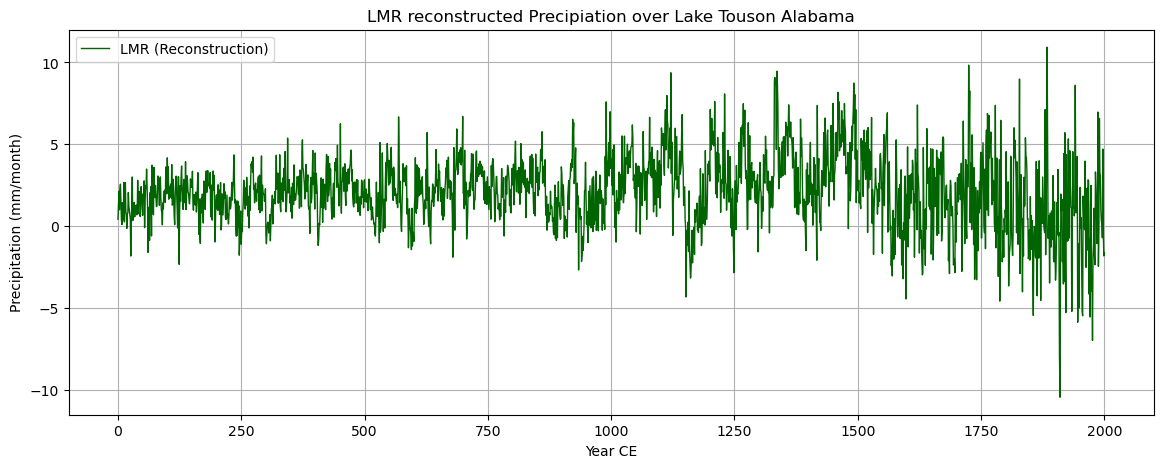

In [43]:
plt.figure(figsize=(14, 5)) 
plt.plot(df_lmry['year'], df_lmry['prate'], color="darkgreen", lw=1, label="LMR (Reconstruction)") 
plt.title("LMR reconstructed Precipiation over Lake Touson Alabama") 
plt.xlabel("Year CE") 
plt.ylabel("Precipitation (mm/month)") 
plt.legend() 
plt.grid(True) 
plt.show()

### 30-Year Running Mean
Smoothing the record helps visualize long-term climate trends.

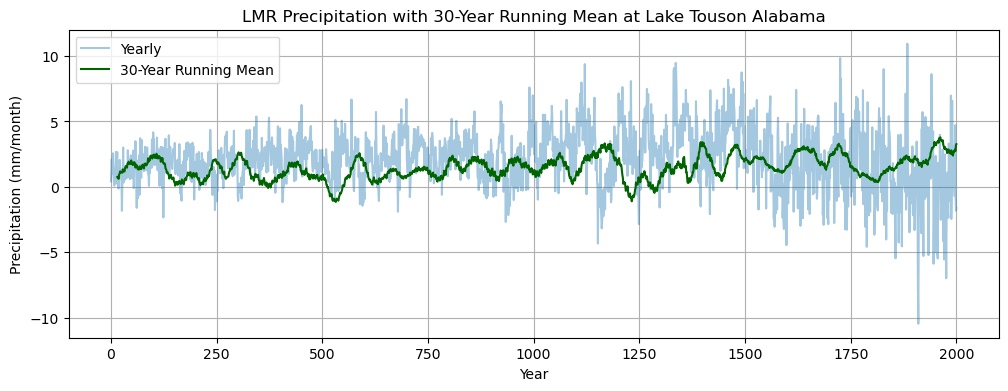

In [44]:
df_lmry['precip_30yr_mean'] = df_lmr['prate'].rolling(window=30, center=True).mean() 
plt.figure(figsize=(12,4)) 
plt.plot(df_lmry['year'], df_lmry['prate'], alpha=0.4, label='Yearly') 
plt.plot(df_lmry['year'], df_lmry['precip_30yr_mean'], color='darkgreen', label='30-Year Running Mean') 
plt.title('LMR Precipitation with 30-Year Running Mean at Lake Touson Alabama') 
plt.xlabel('Year') 
plt.ylabel('Precipitation (mm/month)') 
plt.legend() 
plt.grid(True) 
plt.show()

### Histogram of Precipitation 
Let's look at how precipitation values are distributed across the millennium.

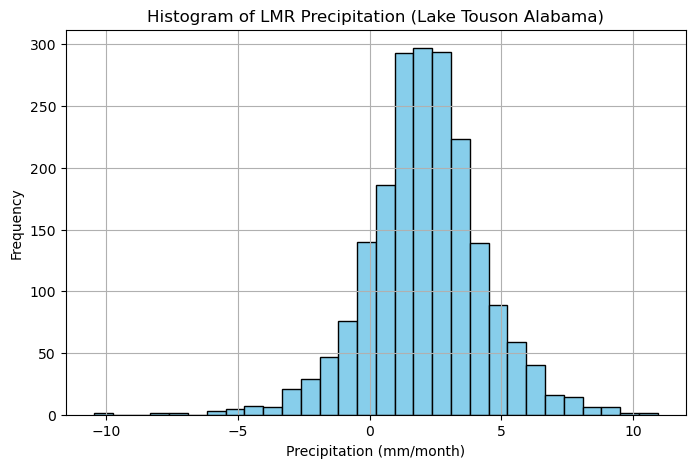

In [45]:
plt.figure(figsize=(8,5)) 
plt.hist(df_lmry['prate'].dropna(), bins=30, color='skyblue', edgecolor='black') 
plt.title('Histogram of LMR Precipitation (Lake Touson Alabama)') 
plt.xlabel('Precipitation (mm/month)') 
plt.ylabel('Frequency') 
plt.grid(True) 
plt.show()

### Precipitation by Century 
This boxplot compares variability across centuries.

<Figure size 1000x500 with 0 Axes>

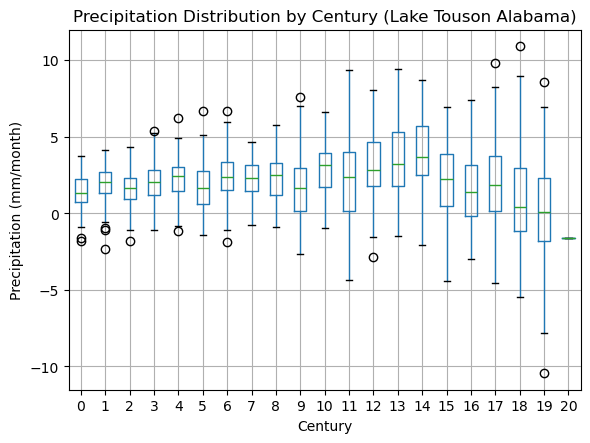

In [46]:
df_lmry['century'] = (df_lmry['year'] // 100) 
plt.figure(figsize=(10,5)) 
df_lmry.boxplot(column='prate', by='century', grid=True) 
plt.title('Precipitation Distribution by Century (Lake Touson Alabama)') 
plt.suptitle('') 
plt.xlabel('Century') 
plt.ylabel('Precipitation (mm/month)') 
plt.show()

## Conclusion
This exploration of the Last Millennium Reanalysis (LMR) precipitation data for Alabama reveals: 
- Multi-decadal variability in reconstructed precipitation
- Long-term fluctuations
- A pronounced range of wet and dry centuries
- These reconstructed data provide valuable insights into paleoclimate hydrovariability in Alabama over the past millennium.